In [49]:
import warnings
warnings.filterwarnings("ignore")

In [50]:
import pandas as pd

In [51]:
pd.read_csv(r"C:\Users\HP\Downloads\Attrition.csv")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [52]:
at=pd.read_csv(r"C:\Users\HP\Downloads\Attrition.csv")

In [53]:
at.isnull().sum()[at.isnull().sum()>0]

Series([], dtype: int64)

In [54]:
at.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [55]:
at.Attrition.value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [56]:
at.Attrition.replace({'No':0,'Yes':1},inplace=True)

In [57]:
at.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [58]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [59]:
at[at.select_dtypes(include='object').columns]=at[at.select_dtypes(include='object').columns].apply(le.fit_transform)

In [60]:
at.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [61]:
from sklearn.model_selection import train_test_split
at_train,at_test=train_test_split(at,test_size=.2)

In [62]:
# over sampling
df1=at_train[at_train.Attrition==1]
at_train=pd.concat([at_train,df1])
at_train.shape

(1370, 35)

In [63]:
at_train_x=at_train.iloc[::,at.columns!='Attrition']
at_train_y=at_train.Attrition

In [64]:
at_test_x=at_test.iloc[::,at.columns!='Attrition']
at_test_y=at_test.Attrition

In [65]:
at_test_y

355     0
892     1
625     0
1375    1
1320    0
       ..
1303    0
1088    0
1239    0
170     0
425     0
Name: Attrition, Length: 294, dtype: int64

In [66]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=250,criterion="entropy",)

In [67]:
rfc.fit(at_train_x,at_train_y)

,n_estimators,250
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
#pred_train=rfc.predict(at_train_x)
pred_test=rfc.predict(at_test_x)
pred_test

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [69]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

In [70]:
mat=confusion_matrix(at_test_y,pred_test)

In [71]:
mat

array([[245,   6],
       [ 31,  12]])

In [72]:
accuracy_score(at_test_y,pred_test)

0.8741496598639455

In [73]:
recall_score(at_test_y,pred_test)

0.27906976744186046

In [74]:
precision_score(at_test_y,pred_test)

0.6666666666666666

In [75]:
f1_score(at_test_y,pred_test)

0.39344262295081966

In [76]:
pred_prob_test=rfc.predict_proba(at_test_x)

In [77]:
from sklearn.metrics import roc_auc_score,roc_curve

In [78]:
roc_auc_score(at_test_y,pred_prob_test[:,1])

0.8403594922635041

In [79]:
fpr,tpr,thr=roc_curve(at_test_y,pred_prob_test[:,1])

In [80]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'arouc curve')

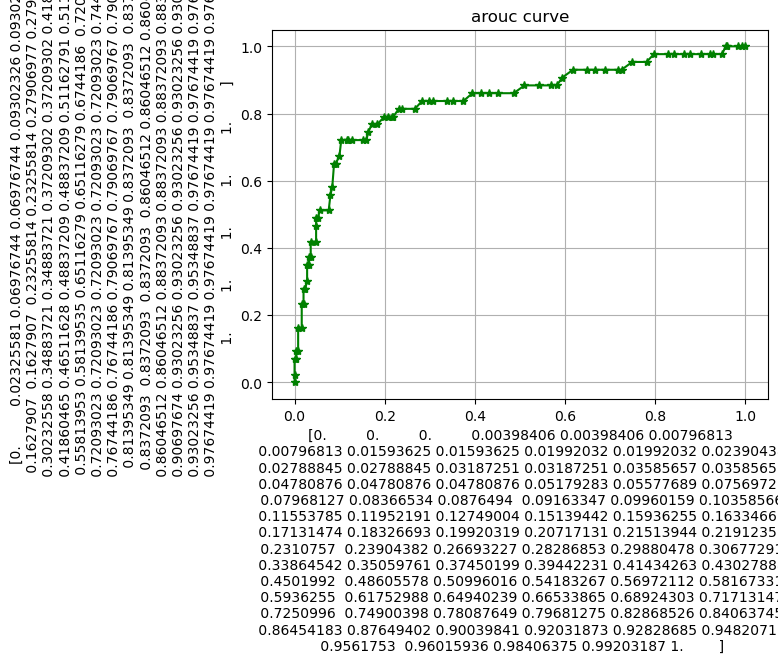

In [81]:
plt.plot(fpr,tpr,marker='*',color='green')
plt.xlabel(fpr)
plt.ylabel(tpr)
plt.grid()
plt.title('arouc curve')

In [82]:
at.Attrition.value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [83]:
from sklearn.model_selection import GridSearchCV

In [84]:
search_dict = {"n_estimators":[2,5,10,15,20,25],
    'criterion':['gini','entropy'],
              'max_depth':range(4,9),
              'min_samples_split':[50,75,100]}

In [85]:
dt_at=RandomForestClassifier()
grid=GridSearchCV(dt_at,param_grid=search_dict,cv=5,scoring="f1_macro")

In [86]:
grid.fit(at_train_x,at_train_y)

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(4, 9), 'min_samples_split': [50, 75, ...], 'n_estimators': [2, 5, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,2


In [87]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 8,
 'min_samples_split': 50,
 'n_estimators': 2}

In [88]:
grid.best_score_

np.float64(0.6862683469864408)

In [89]:
import sklearn
sklearn.metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

# Cross Validation 

In [90]:
import pandas as pd

In [91]:
pd.read_csv(r"C:\Users\HP\Downloads\trainRF.csv")

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [92]:
mp=pd.read_csv(r"C:\Users\HP\Downloads\trainRF.csv")

In [93]:
mp.isnull().sum()[mp.isnull().sum()>0]

Series([], dtype: int64)

In [94]:
from sklearn.model_selection import train_test_split
mp_train,mp_test=train_test_split(mp,train_size=.2)

In [95]:
mp_train_x=mp_train.iloc[::,:-1]
mp_train_y=mp_train.iloc[::,-1]

In [96]:
mp_test_x=mp_test.iloc[::,:-1]
mp_test_y=mp_test.iloc[::,-1]

In [97]:
from sklearn.model_selection import cross_val_score

In [98]:
from sklearn.tree import DecisionTreeClassifier
dt_mp=DecisionTreeClassifier()

In [99]:
dt_mp.fit(mp_train_x,mp_train_y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [100]:
score_dt_mp=cross_val_score(dt_mp,mp_train_x,mp_train_y,cv=5)

In [101]:
score_dt_mp

array([0.7625, 0.7625, 0.7875, 0.8   , 0.6875])

In [102]:
score_dt_mp.min()

np.float64(0.6875)

In [103]:
score_dt_mp.max()

np.float64(0.8)

In [104]:
score_dt_mp.mean()

np.float64(0.76)